# Regression Model Comparison

**Owner: Student 2 | Review 1 - Regression Track**  
This notebook consolidates test metrics for all ten required regression algorithms. Student 1's four results are taken from the executed notebooks at commit `7e5bb39`; the remaining results are loaded from this folder's executed notebooks.

,Rank,Model,R2,RMSE,MAE,CV_R2
6,1,Random Forest Regressor,0.970,2101.323,529.470,0.958
9,2,KNN Regressor,0.959,2470.085,719.862,0.949
5,3,Decision Tree Regressor,0.950,2735.639,498.489,0.929
7,4,Gradient Boosting Regressor,0.894,3977.901,2403.873,0.887
4,5,Polynomial Regression,0.817,5228.017,3357.131,0.814
2,6,Lasso Regression,0.764,5947.692,3865.833,0.759
1,7,Ridge Regression,0.763,5958.164,3926.969,0.759
0,8,Linear Regression,0.762,5962.121,3929.924,NaN
3,9,ElasticNet Regression,0.756,6040.768,4150.476,0.752
8,10,Support Vector Regressor,0.614,7601.838,3844.826,0.538


Best model by R2: Random Forest Regressor (0.9705)


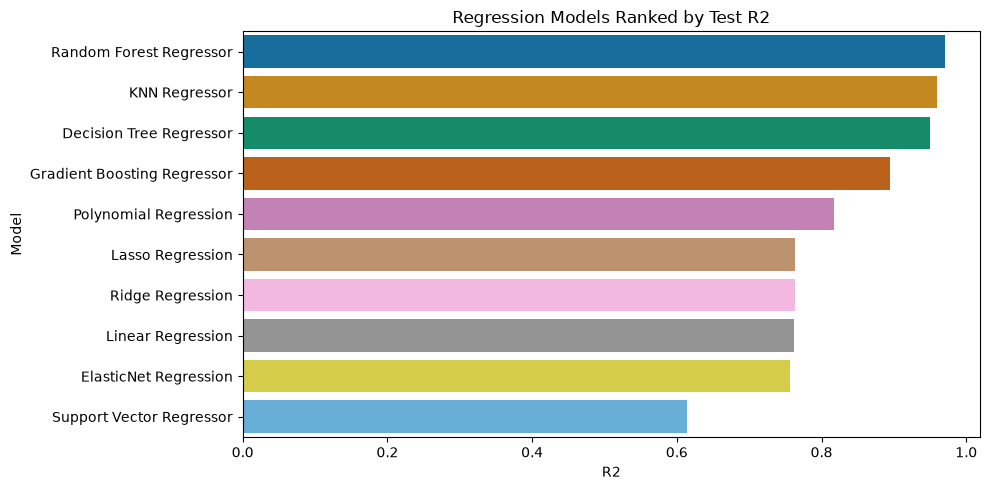

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

repo_root = next(
    (parent for parent in (Path.cwd(), *Path.cwd().parents) if (parent / "data" / "health_insurance.csv").exists()),
    None,
)
if repo_root is None:
    raise FileNotFoundError("Run this notebook from inside the ML-301 repository.")

student_1_results_dir = repo_root / "student_work" / "student_1" / "results"
student_1_results = pd.concat(
    [pd.read_csv(path) for path in sorted(student_1_results_dir.glob("0[1-4]_*.csv"))],
    ignore_index=True,
)

results_dir = repo_root / "student_work" / "student_2" / "results"
other_results = pd.concat(
    [pd.read_csv(path) for path in sorted(results_dir.glob("*.csv"))], ignore_index=True
)
comparison = pd.concat([student_1_results, other_results], ignore_index=True).sort_values("R2", ascending=False)
comparison.insert(0, "Rank", range(1, len(comparison) + 1))
display(comparison.round(3))
best = comparison.iloc[0]
print(f"Best model by R2: {best['Model']} ({best['R2']:.4f})")
assert len(comparison) == 10

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison, x="R2", y="Model", hue="Model", palette="colorblind", legend=False)
plt.title("Regression Models Ranked by Test R2")
plt.tight_layout()
plt.show()

The final choice should balance held-out R2, RMSE, MAE, and five-fold stability. Residual and predicted-vs-actual plots are saved in each candidate's notebook; tree-based notebooks also include feature importance.